# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty to the mean squared error stops it from making the coefficients super large to fit the trianing data better. It forces the model to stay simple and not overfit noise
2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization allows us to have control over how complex we want the model to be by changing the penalty around. We move across the bias variance spectrum by either having a small penalty which equates to low bias/high variance versus a large penalty which equates to a high bias/low variance.
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge shrinks coefficients but keeps all coefficients while LASSO will shrink some coefficients to 0, performing feature selection to only pick the most important variables.

4. How do we typically scale variables for use in regularized regression? Why?

We subtract mean and divide by standard deviation to standardize our variables and ensure that the penalty affects all variables the same.

5. How is the penalty $\alpha$ typically selected?

We hand pick the alpha by cross validating a bunch of values and picking the one with the lowest validation error.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No. You do not include the penalty term in evaluating the cross validated MSE because the penalty is only for training, not something we care about when looking at performance.


**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
#1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./data/cars_hw.csv')
df['Age'] = df['Make_Year'].max() - df['Make_Year']

X = df[['Mileage_Run', 'Age']]
y = df['Price']
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(X.columns)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


In [2]:
#2
ols = LinearRegression()
ols.fit(X_scaled, y)

ols_results = pd.DataFrame({
    'feature': feature_names,
    'ols_coef': ols.coef_
})
print(ols_results)

# The interaction between Mileage_Run and Age is negative.

             feature       ols_coef
0        Mileage_Run  458071.119627
1                Age -136698.072100
2      Mileage_Run^2  -91643.120024
3    Mileage_Run Age -898405.751356
4              Age^2  113603.822348
5      Mileage_Run^3  -65144.896599
6  Mileage_Run^2 Age  229021.676556
7  Mileage_Run Age^2  368955.713359
8              Age^3  -84038.066146


In [4]:
#3
alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)

LassoCV(alphas=array([  10.        ,   12.74274986,   16.23776739,   20.69138081,
         26.36650899,   33.59818286,   42.81332399,   54.55594781,
         69.51927962,   88.58667904,  112.88378917,  143.84498883,
        183.29807108,  233.57214691,  297.63514416,  379.26901907,
        483.29302386,  615.84821107,  784.75997035, 1000.        ]),
        cv=20, max_iter=10000)

Text(0.5, 1.0, 'MSE by Alpha')

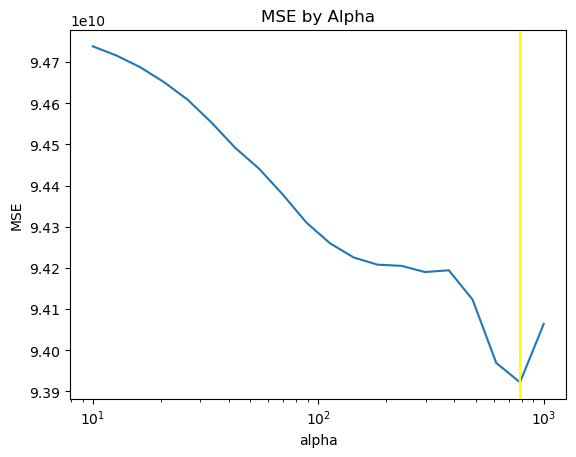

In [10]:
#4
mean_mse = lasso.mse_path_.mean(axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.axvline(lasso.alpha_, color='yellow')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('MSE by Alpha')


c:\Users\antho\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 141463082618.25, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\antho\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 541616931508.0, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\antho\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 571380444901.125, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\antho\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: 

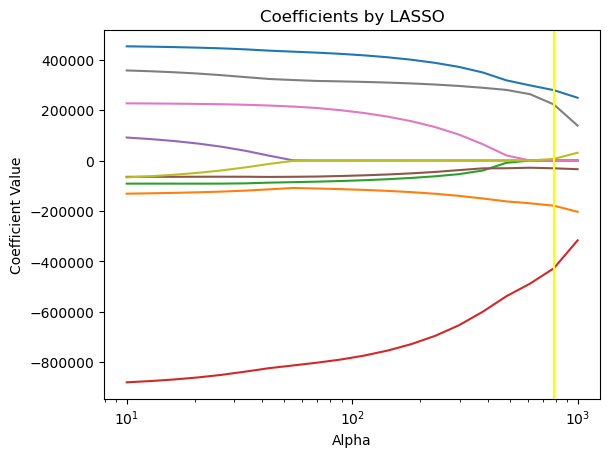

In [14]:
#5
alphas_path, coefs, _ = lasso_path(X_scaled, y, alphas=alphas)

for i in range(coefs.shape[0]):
    plt.plot(alphas_path, coefs[i])

plt.axvline(lasso.alpha_, color= 'yellow')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Coefficients by LASSO')
plt.show()


In [23]:
#6
selected = lasso.coef_ != 0
print("Selected Features:", feature_names[selected])
prop_zero = (lasso.coef_ == 0).mean()
print(prop_zero)
#LASSO removed 33% of features which means 67% of features were selected.

Selected Features: ['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Mileage_Run Age^2'
 'Age^3']
0.3333333333333333


#7 No coefficients increase in magnitude from regression to LASSO. A few coefficients change sign but only because LASSO set them to 0. My LASSO kept a lot of variables even including the higher order variables like Age^3 which was sort of strange to me.


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?